# Predicción de Ventas - Rossmann Analytics
## Fase 1: Ingesta de Datos, Transformación y Exploración (EDA)

En este cuaderno construiremos los cimientos de nuestro proyecto. Realizaremos la carga masiva de datos optimizando la memoria, enriqueceremos la información mediante fuentes externas, y llevaremos a cabo un análisis visual para comprender el comportamiento del negocio antes de entrenar la IA.
***

### 1. Ingesta de Datos Masivos (Big Data)
El dataset principal de ventas (`train.csv`) contiene más de **1.000.000 de registros**. Para evitar cuellos de botella y optimizar el uso de memoria RAM, utilizaremos la librería **Dask** para la lectura paralela. El catálogo de sucursales (`store.csv`), al ser más ligero, lo manejaremos de forma tradicional con Pandas.

In [9]:
import pandas as pd
import dask.dataframe as dd 

# 1. IMPORTACIÓN Y BIG DATA
print("Cargando y procesando datos masivos con Dask...")

ddf_ventas = dd.read_csv('../data/train.csv', dtype={'StateHoliday': 'object'})

# Eliminamos los días en que las tiendas están cerradas (Open == 0) o no hay ventas.
ddf_ventas_optimizadas = ddf_ventas[ddf_ventas['Open'] != 0]

# Pasamos el dataset reducido y manejable a Pandas
df_ventas = ddf_ventas_optimizadas.compute() 

# Cargamos el archivo de tiendas (usando Pandas directamente)
df_tiendas = pd.read_csv('../data/store.csv') 

print(f"Datos optimizados y cargados. Filas en ventas (solo días abiertos): {len(df_ventas)}")

Cargando y procesando datos masivos con Dask...
Datos optimizados y cargados. Filas en ventas (solo días abiertos): 844392


### 2. Enriquecimiento vía API (Datos Externos)
El contexto es vital para la IA. Las ventas en retail varían drásticamente dependiendo de los días no laborables. Vamos a consumir una API REST pública (`date.nager.at`) para extraer el calendario de festivos de Alemania en formato JSON y convertirlo en un DataFrame.

In [10]:
import requests
import pandas as pd

print("Obteniendo calendario de festivos de Alemania (API)...")

# Llamamos a una API pública de festivos
url_api = "https://date.nager.at/api/v3/PublicHolidays/2015/DE"
respuesta = requests.get(url_api)

if respuesta.status_code == 200:
    # Convertimos el JSON de la API directamente a un DataFrame de Pandas
    festivos_json = respuesta.json()
    df_festivos = pd.DataFrame(festivos_json)
    
    print("Datos JSON cargados con éxito desde la API")
    display(df_festivos[['date', 'localName', 'name']].head())
else:
    print(f"Error al conectar con la API. Código: {respuesta.status_code}")

Obteniendo calendario de festivos de Alemania (API)...
Datos JSON cargados con éxito desde la API


,date,localName,name
0,2015-01-01,Neujahr,New Year's Day
1,2015-01-06,Heilige Drei Könige,Epiphany
2,2015-04-03,Karfreitag,Good Friday
3,2015-04-05,Ostersonntag,Easter Sunday
4,2015-04-06,Ostermontag,Easter Monday


Una vez obtenidos los datos de la API, procedemos a unificarlos con nuestro *dataset* principal utilizando la fecha como clave de unión (*Left Join*). Esto nos permite enriquecer la tabla visualmente para saber exactamente qué festividad alemana afectó a cada registro de ventas.

> **Decisión Arquitectónica:** Este cruce se realiza **exclusivamente con fines de Análisis Exploratorio (EDA)** y demostración de competencias técnicas (Data Wrangling). Para garantizar la máxima estabilidad algorítmica y evitar fugas de datos o ruido temporal (la llamada a la API se limitó al año 2015 por eficiencia), este *dataset* cruzado no se inyectará en la fase de modelado. El *Random Forest* se entrenará de forma robusta utilizando únicamente las variables estructurales consolidadas del negocio.

In [11]:
# Cruce de datos
df_master_demo = pd.merge(df_ventas, df_tiendas, on='Store', how='left')

# Preparación de la Key para el cruce
# Aseguramos que las fechas en ambos dataframes
df_master_demo['Date'] = pd.to_datetime(df_master_demo['Date'])
df_festivos['date'] = pd.to_datetime(df_festivos['date'])

# Cruce con los datos de la API
df_cruce_final = pd.merge(
    df_master_demo, 
    df_festivos[['date', 'localName']],
    left_on='Date', 
    right_on='date', 
    how='left'
)

# Limpieza visual
df_cruce_final['localName'] = df_cruce_final['localName'].fillna('Día Laborable/Normal')

# Eliminamos la columna duplicada de fecha que viene de la API
df_cruce_final = df_cruce_final.drop(columns=['date'])

print(f"Dataset final con {len(df_cruce_final)} filas.")

# Visualización
print("\nDemostración: Muestra de ventas cruzadas con un festivo de la API:")
dias_festivos = df_cruce_final[df_cruce_final['localName'] != 'Día Laborable/Normal']
display(dias_festivos[['Store', 'Date', 'Sales', 'StoreType', 'localName']].head(5))

Dataset final con 844392 filas.

Demostración: Muestra de ventas cruzadas con un festivo de la API:


,Store,Date,Sales,StoreType,localName
54835,2,2015-06-04,5810,a,Fronleichnam
54836,4,2015-06-04,10200,c,Fronleichnam
54837,5,2015-06-04,5807,a,Fronleichnam
54838,6,2015-06-04,5749,a,Fronleichnam
54839,7,2015-06-04,9696,a,Fronleichnam


### 3. Transformación e Integración de Datos
Con nuestras fuentes de datos cargadas, procedemos a unificar la información mediante cruces relacionales (`merge`). En este paso también limpiaremos el formato de las fechas y crearemos lógicas de negocio personalizadas (como el cálculo del nivel de competencia) para facilitar el aprendizaje de los algoritmos predictivos.

In [ ]:
# 2. TRANSFORMACIONES - Cruce de datos 
df_master = pd.merge(df_ventas, df_tiendas, on='Store', how='left')

# Convertimos la fecha a formato DateTime
df_master['Date'] = pd.to_datetime(df_master['Date'], format='%Y-%m-%d')

# 3. MAPEO  - Convertimos códigos en nombres legibles
dict_tiendas = {
    'a': 'Estándar', 
    'b': 'Alto Tráfico', 
    'c': 'Pequeña', 
    'd': 'Hipermercado'
}
df_master['StoreType_Name'] = df_master['StoreType'].map(dict_tiendas)

print("Tablas unidas en df_master correctamente.")

Tablas unidas en df_master correctamente.


In [13]:
# 4. ORDENACIÓN

# Ordenar por fecha y por volumen de ventas (de mayor a menor)
df_sorted = df_master.sort_values(by=['Date', 'Sales'], ascending=[True, False])

print("Datos ordenados por fecha y ventas.")

# Ver el top 10 de registros con más ventas
df_sorted[['Store', 'Date', 'Sales', 'Customers', 'StoreType_Name']].head(10)

def categorizar_distancia(distancia):
    if pd.isna(distancia):
        return 'Desconocido'
    elif distancia < 1000:
        return 'Competencia Fuerte (Cerca)'
    else:
        return 'Competencia Débil (Lejos)'

# Aplicamos la función a la columna
df_master['Nivel_Competencia'] = df_master['CompetitionDistance'].apply(categorizar_distancia)

print("Columna creada usando .apply()")

Datos ordenados por fecha y ventas.
Columna creada usando .apply()


### 4. Análisis Exploratorio Visual (EDA)
Una vez limpio el *Dataset Maestro*, nos hacemos las primeras preguntas de negocio: ¿Qué modelo de tienda es el más rentable? ¿Qué impacto real tienen las campañas promocionales? Utilizamos la potencia de **Seaborn** para visualizar estos patrones.

Resumen por Tipo de Tienda:
                                       Ventas_Totales  Ventas_Promedio  \
StoreType_Name                                                           
Estándar (Calle)                           3165334859      6925.167661   
Hipermercado (Afueras)                     1765392943      6822.141881   
Pequeña (Barrio)                            783221426      6932.512755   
Alto Tráfico (Estaciones/Aeropuertos)       159231395     10231.407505   

                                       Dias_con_Promo  
StoreType_Name                                         
Estándar (Calle)                               204521  
Hipermercado (Afueras)                         115697  
Pequeña (Barrio)                                50738  
Alto Tráfico (Estaciones/Aeropuertos)            5940  


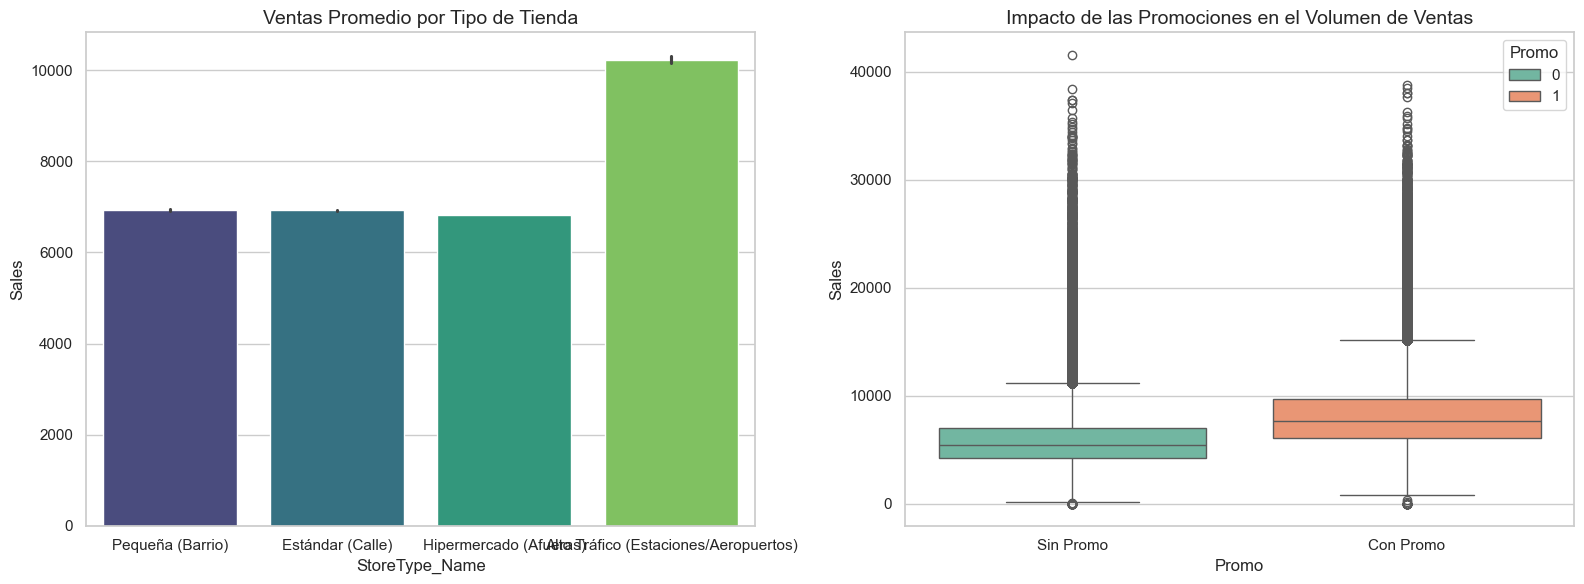

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupaciones complejas (Group by + Aggregation)
df_resumen = df_master.groupby('StoreType_Name').agg(
    Ventas_Totales=('Sales', 'sum'),
    Ventas_Promedio=('Sales', 'mean'),
    Dias_con_Promo=('Promo', 'sum')
).sort_values(by='Ventas_Totales', ascending=False)

print("Resumen por Tipo de Tienda:")
print(df_resumen)

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# 5. VISUALIZACIÓN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1
sns.barplot(data=df_master, x='StoreType_Name', y='Sales', palette='viridis', hue='StoreType_Name', legend=False, ax=axes[0])
axes[0].set_title('Ventas Promedio por Tipo de Tienda', fontsize=14)

# Gráfico 2
sns.boxplot(data=df_master, x='Promo', y='Sales', palette='Set2', hue='Promo', ax=axes[1])
axes[1].set_title('Impacto de las Promociones en el Volumen de Ventas', fontsize=14)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Sin Promo', 'Con Promo'])

# Ajustamos el espacio para que no se pisen los textos
plt.tight_layout()
plt.show()

### 5. Integración Multilenguaje (Python + R)
Para demostrar la interoperabilidad entre herramientas de Data Science, ejecutaremos un proceso en segundo plano. Python preparará una muestra de datos y se la enviará a **R**, cuyo motor estadístico generará un gráfico avanzado utilizando `ggplot2`, devolviendo la imagen directamente a nuestro cuaderno interactivo.

1. Python: Preparando datos para enviar a R...
2. Python: Escribiendo el script de R...
3. Ejecutando motor de R en segundo plano...
Aviso: 'Rscript' no se encontró en el PATH. Usando ruta alternativa.
Gráfico de R generado con éxito


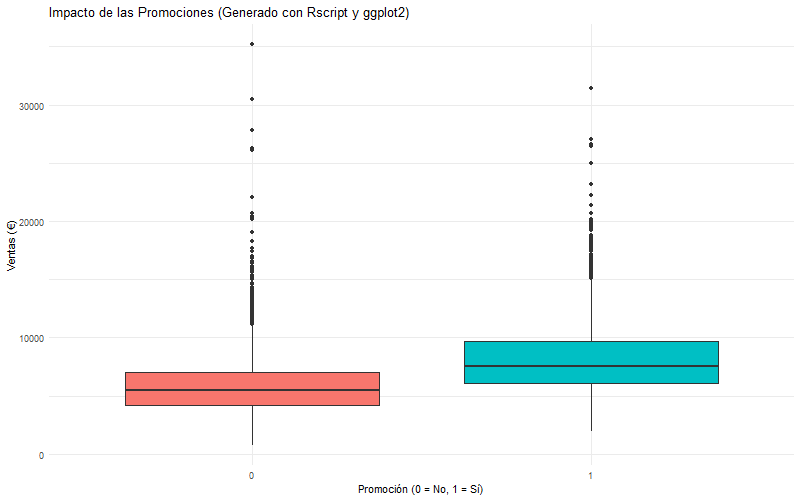

5. Limpiando archivos temporales...


In [7]:
import pandas as pd
import subprocess
from IPython.display import Image, display
import os
import shutil

print("1. Python: Preparando datos para enviar a R...")
# Guardamos una muestra de los datos en un CSV para que R lo lea
df_master[['Promo', 'Sales']].dropna().sample(5000, random_state=42).to_csv('datos_para_r.csv', index=False)

print("2. Python: Escribiendo el script de R...")
# Creamos el código de R puro como texto
codigo_r = """
if (!require("ggplot2")) install.packages("ggplot2", repos="http://cran.us.r-project.org")
library(ggplot2)

datos <- read.csv('datos_para_r.csv')

png('grafico_r.png', width=800, height=500)
ggplot(datos, aes(x=factor(Promo), y=Sales, fill=factor(Promo))) +
  geom_boxplot() +
  theme_minimal() +
  labs(
    title="Impacto de las Promociones (Generado con Rscript y ggplot2)",
    x="Promoción (0 = No, 1 = Sí)",
    y="Ventas (€)"
  ) +
  theme(legend.position="none")
invisible(dev.off())
"""

with open("script_analisis.R", "w", encoding="utf-8") as f:
    f.write(codigo_r)

print("3. Ejecutando motor de R en segundo plano...")

# Intentamos encontrar 'Rscript' automáticamente en las variables de entorno del sistema
ruta_rscript = shutil.which("Rscript")

# Si el sistema no lo encuentra automáticamente, usamos una ruta directa
if ruta_rscript is None:
    print("Aviso: 'Rscript' no se encontró en el PATH. Usando ruta alternativa.")
    # MODIFICAR ESTA RUTA SI EL USUARIO TIENE R EN OTRO DIRECTORIO
    ruta_rscript = r"C:\Program Files\R\R-4.4.1\bin\Rscript.exe" 

try:
    subprocess.run([ruta_rscript, "script_analisis.R"], check=True)
    print("Gráfico de R generado con éxito")
    
    display(Image(filename='grafico_r.png'))
    
    print("5. Limpiando archivos temporales...")
    for archivo in ['datos_para_r.csv', 'script_analisis.R', 'grafico_r.png']:
        if os.path.exists(archivo):
            os.remove(archivo)
    
except FileNotFoundError:
    print(f"Error: No se encuentra el motor de R. Revisa que R esté instalado o ajusta la ruta manual.")
except subprocess.CalledProcessError as e:
    print(f"Error interno al ejecutar el código de R. Revisa el script generado.")
except Exception as e:
    print(f"Error inesperado: {e}")

### 6. Exportación Eficiente (Punto de Control)
Nuestro *Dataset Maestro* ya está limpio, integrado y listo para ser consumido por la Inteligencia Artificial. Para transferir esta información al cuaderno de modelado, guardaremos los datos en formato **Parquet**. Este formato de almacenamiento columnar de Big Data es infinitamente más rápido de leer y comprime los datos de forma mucho más eficiente que un CSV tradicional.

In [8]:
# EXPORTAMOS LOS DATOS LIMPIOS PARA EL SIGUIENTE NOTEBOOK
print("Guardando df_master limpio para el cuaderno de entrenamiento...")

# Usamos formato .parquet
df_master.to_parquet('../data/df_master_limpio.parquet', index=False)

print("Datos guardados en data/df_master_limpio.parquet")

Guardando df_master limpio para el cuaderno de entrenamiento...
Datos guardados en data/df_master_limpio.parquet
